# Cross-Metric Predictability: 7 MOIs

Test whether pre-stimulus metric X predicts post-stimulus metric Y for **all metric combinations**.

## Motivation

Within-metric predictability (pre-Salience → post-Salience) was poor for most metrics. But do brain states generalize *across* metrics?

E.g., does high pre-stimulus **Salience** predict high post-stimulus **Complexity** or **Entrainment**?

## Analysis

For each (subject, session, pre_metric, post_metric) tuple:
1. Extract trials where both metrics have valid data
2. Train OLS: `post_metric ~ pre_metric` on training folds
3. Evaluate out-of-sample R² and correlation on held-out fold
4. Produces 7×7 = 49 metric pairs per session

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from itertools import product
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Metrics of interest (6 MOIs - excluding Complexity due to poor sign stability)
METRICS_7_ORDER = [
    'salience',
    'dynamic_functional_connectivity_matrix_var_mat',
    'max_dynamic_network_profile',
    'phase_coherence_matrix_mean_mat',
    'N1',
    'N2',
]

# Display labels
METRICS_7_LABELS = [
    'Salience',
    'Fluidity',
    'Peak Synchrony',
    'Entrainment',
    'N1_amplitude',
    'N2_amplitude',
]

METRIC_LABEL_MAP = dict(zip(METRICS_7_ORDER, METRICS_7_LABELS))

In [3]:
# Resolve project root
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'ieeg_metrics'
print(f'Project root: {project_root}')

Project root: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main


In [4]:
# Load df_9MOIs
csv_path_9mois = metrics_root / 'df_9MOIs_ieeg.csv'
df = pd.read_csv(csv_path_9mois)

# Convert metric_name to ordered categorical
df['metric_name'] = pd.Categorical(
    df['metric_name'],
    categories=METRICS_7_ORDER,
    ordered=True,
)

# Filter for radius_pre=100, radius_post=100 only
df = df[(df['radius_pre'] == 100) & (df['radius_post'] == 100)].copy()

print(f'Loaded data: {df.shape}')
print(f'Unique subjects: {df["sub"].nunique()}')
print(f'Unique sessions: {df["run_is"].nunique()}')
print(f'Unique metrics: {df["metric_name"].nunique()}')

Loaded data: (98370, 8)
Unique subjects: 36
Unique sessions: 17
Unique metrics: 7


In [5]:
def compute_cross_metric_cv(pre_vals, post_vals, n_splits=5, random_state=42):
    """
    Compute out-of-sample R² and correlation for a cross-metric pair.
    
    Parameters:
    -----------
    pre_vals : array-like
        Pre-stimulus metric values
    post_vals : array-like
        Post-stimulus metric values
    n_splits : int
        Number of CV folds
    random_state : int
        Random seed
    
    Returns:
    --------
    oos_r2 : float
        Mean out-of-sample R²
    oos_r2_std : float
        Std dev of out-of-sample R²
    oos_corr : float
        Mean out-of-sample correlation
    oos_corr_std : float
        Std dev of out-of-sample correlation
    within_corr : float
        Within-sample correlation
    n_trials : int
        Number of valid trials
    """
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()
    
    # Remove NaN pairs
    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    n_trials = len(pre_vals)
    
    if n_trials < n_splits or n_trials < 3:
        return np.nan, np.nan, np.nan, np.nan, np.nan, n_trials
    
    # Within-sample correlation
    within_corr, _ = pearsonr(pre_vals, post_vals)
    
    # K-fold CV
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores = []
    corr_scores = []
    
    for train_idx, test_idx in kf.split(pre_vals):
        X_train = pre_vals[train_idx].reshape(-1, 1)
        X_test = pre_vals[test_idx].reshape(-1, 1)
        y_train = post_vals[train_idx]
        y_test = post_vals[test_idx]
        
        # Fit OLS
        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Out-of-sample R²
        ss_res = np.sum((y_test - y_pred) ** 2)
        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
        r2_scores.append(r2)
        
        # Out-of-sample correlation
        corr, _ = pearsonr(y_test, y_pred)
        corr_scores.append(corr)
    
    r2_scores = np.array(r2_scores)
    corr_scores = np.array(corr_scores)
    
    return (
        np.mean(r2_scores),
        np.std(r2_scores),
        np.mean(corr_scores),
        np.std(corr_scores),
        within_corr,
        n_trials
    )

In [23]:
# Compute cross-metric predictability for each session
# Pivot to wider format for easier cross-metric lookups

results = []
n_sessions = df.groupby(['sub', 'run_is']).ngroups
n_metric_pairs = len(METRICS_7_ORDER) ** 2

print(f'Computing {n_metric_pairs} metric pairs × {n_sessions} sessions...')
print(f'Expected rows: ~{n_metric_pairs * n_sessions}\n')

counter = 0
for (sub, run), session_df in df.groupby(['sub', 'run_is']):
    # Pivot to get trials × metrics matrix
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean'
    )
    
    # Extract pre and post matrices
    pre_cols = [col for col in pivot.columns if col[0] == 'metric_value_pre']
    post_cols = [col for col in pivot.columns if col[0] == 'metric_value_post']
    
    # Test all metric pair combinations
    for pre_metric, post_metric in product(METRICS_7_ORDER, repeat=2):
        # Get pre and post vectors for this pair
        pre_key = ('metric_value_pre', pre_metric)
        post_key = ('metric_value_post', post_metric)
        
        if pre_key not in pivot.columns or post_key not in pivot.columns:
            continue
        
        pre_vals = pivot[pre_key].values
        post_vals = pivot[post_key].values
        
        # Count valid pairs for n_splits calculation
        mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
        n_trials_pair = np.sum(mask)
        
        # Compute CV scores
        oos_r2, oos_r2_std, oos_corr, oos_corr_std, within_corr, n_trials = compute_cross_metric_cv(
            pre_vals, post_vals, n_splits=2
        )
        
        results.append({
            'sub': sub,
            'run_is': run,
            'pre_metric': pre_metric,
            'post_metric': post_metric,
            'pre_metric_label': METRIC_LABEL_MAP.get(pre_metric, pre_metric),
            'post_metric_label': METRIC_LABEL_MAP.get(post_metric, post_metric),
            'n_trials': n_trials,
            'within_sample_corr': within_corr,
            'oos_r2': oos_r2,
            'oos_r2_std': oos_r2_std,
            'oos_corr': oos_corr,
            'oos_corr_std': oos_corr_std,
        })
        
        counter += 1
        if counter % 100 == 0:
            print(f'Computed {counter} pairs...')

df_cross = pd.DataFrame(results)
print(f'\nComputed {len(df_cross)} cross-metric pairs')
print(f'Shape: {df_cross.shape}')
df_cross.head(10)

Computing 49 metric pairs × 318 sessions...
Expected rows: ~15582

Computed 100 pairs...
Computed 200 pairs...
Computed 300 pairs...
Computed 400 pairs...
Computed 500 pairs...
Computed 600 pairs...
Computed 700 pairs...
Computed 800 pairs...
Computed 900 pairs...
Computed 1000 pairs...
Computed 1100 pairs...
Computed 1200 pairs...
Computed 1300 pairs...
Computed 1400 pairs...
Computed 1500 pairs...
Computed 1600 pairs...
Computed 1700 pairs...
Computed 1800 pairs...
Computed 1900 pairs...
Computed 2000 pairs...
Computed 2100 pairs...
Computed 2200 pairs...
Computed 2300 pairs...
Computed 2400 pairs...
Computed 2500 pairs...
Computed 2600 pairs...
Computed 2700 pairs...
Computed 2800 pairs...
Computed 2900 pairs...
Computed 3000 pairs...
Computed 3100 pairs...
Computed 3200 pairs...
Computed 3300 pairs...
Computed 3400 pairs...
Computed 3500 pairs...
Computed 3600 pairs...
Computed 3700 pairs...
Computed 3800 pairs...
Computed 3900 pairs...
Computed 4000 pairs...
Computed 4100 pairs...

,sub,run_is,pre_metric,post_metric,pre_metric_label,post_metric_label,n_trials,within_sample_corr,oos_r2,oos_r2_std,oos_corr,oos_corr_std
0,sub-01,run-01,salience,salience,Salience,Salience,40,0.633554,0.401403,0.033868,0.634176,0.026971
1,sub-01,run-01,salience,dynamic_functional_connectivity_matrix_var_mat,Salience,Fluidity,40,0.360605,0.113359,0.008362,0.358153,0.005948
2,sub-01,run-01,salience,max_dynamic_network_profile,Salience,Peak Synchrony,40,0.504651,0.205777,0.059957,0.483665,0.061634
3,sub-01,run-01,salience,Entropy_FC,Salience,Complexity,40,-0.589529,0.342109,0.071824,0.597047,0.064095
4,sub-01,run-01,salience,phase_coherence_matrix_mean_mat,Salience,Entrainment,40,0.459028,0.199020,0.071758,0.448457,0.083423
5,sub-01,run-01,salience,N1,Salience,N1_amplitude,40,0.019686,-0.211555,0.079484,-0.250962,0.039746
6,sub-01,run-01,salience,N2,Salience,N2_amplitude,40,0.014179,-0.203728,0.110239,-0.237450,0.071658
7,sub-01,run-01,dynamic_functional_connectivity_matrix_var_mat,salience,Fluidity,Salience,40,0.739578,0.430756,0.142105,0.720476,0.089907
8,sub-01,run-01,dynamic_functional_connectivity_matrix_var_mat,dynamic_functional_connectivity_matrix_var_mat,Fluidity,Fluidity,40,0.362897,0.095928,0.035623,0.360105,0.040198
9,sub-01,run-01,dynamic_functional_connectivity_matrix_var_mat,max_dynamic_network_profile,Fluidity,Peak Synchrony,40,0.638120,0.109242,0.298712,0.593615,0.229377


In [25]:
# Overall summary
print('\n' + '='*70)
print('CROSS-METRIC PREDICTABILITY SUMMARY')
print('='*70)

print(f'\nMedian within-sample correlation: {df_cross["within_sample_corr"].median():.3f}')
print(f'Median out-of-sample R²: {df_cross["oos_r2"].median():.3f}')
print(f'Median out-of-sample correlation: {df_cross["oos_corr"].median():.3f}')

print(f'\nWithin-sample range: [{df_cross["within_sample_corr"].min():.3f}, {df_cross["within_sample_corr"].max():.3f}]')
print(f'Out-of-sample R² range: [{df_cross["oos_r2"].min():.3f}, {df_cross["oos_r2"].max():.3f}]')
print(f'Out-of-sample corr range: [{df_cross["oos_corr"].min():.3f}, {df_cross["oos_corr"].max():.3f}]')

pct_positive_oos = (df_cross['oos_r2'] > 0).sum() / len(df_cross) * 100
print(f'\nFraction with positive out-of-sample R²: {pct_positive_oos:.1f}%')

# Diagonal (within-metric) vs off-diagonal (cross-metric) comparison
df_cross['is_diagonal'] = df_cross['pre_metric'] == df_cross['post_metric']
diag = df_cross[df_cross['is_diagonal']]['oos_r2'].median()
off_diag = df_cross[~df_cross['is_diagonal']]['oos_r2'].median()

print(f'\nMedian OOS R² (within-metric, diagonal): {diag:.3f}')
print(f'Median OOS R² (cross-metric, off-diagonal): {off_diag:.3f}')


CROSS-METRIC PREDICTABILITY SUMMARY

Median within-sample correlation: 0.149
Median out-of-sample R²: -0.142
Median out-of-sample correlation: 0.248

Within-sample range: [-0.889, 0.952]
Out-of-sample R² range: [-3442.038, 0.819]
Out-of-sample corr range: [-0.755, 0.935]

Fraction with positive out-of-sample R²: 27.3%

Median OOS R² (within-metric, diagonal): -0.100
Median OOS R² (cross-metric, off-diagonal): -0.149


In [26]:
# Save results
output_csv = metrics_root / 'df_cross_metric_predictability_7MOIs.csv'
df_cross.to_csv(output_csv, index=False)
print(f'Saved: {output_csv}')
print(f'Shape: {df_cross.shape}')

Saved: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_cross_metric_predictability_7MOIs.csv
Shape: (15582, 13)


In [9]:
# Per-metric-pair analysis: which pairs predict best?
print('\n' + '='*70)
print('Top 20 Predictive Metric Pairs (by OOS R²)')
print('='*70)

top20 = df_cross.nlargest(20, 'oos_r2')[[
    'pre_metric_label', 'post_metric_label', 'within_sample_corr', 'oos_r2', 'oos_corr'
]].reset_index(drop=True)

for idx, row in top20.iterrows():
    print(f'{idx+1:2d}. {row["pre_metric_label"]:15s} → {row["post_metric_label"]:15s}  '
          f'within={row["within_sample_corr"]:6.3f}  oos_r2={row["oos_r2"]:6.3f}  oos_corr={row["oos_corr"]:6.3f}')


Top 20 Predictive Metric Pairs (by OOS R²)
 1. N2_amplitude    → Salience         within= 0.866  oos_r2= 0.711  oos_corr= 0.909
 2. N2_amplitude    → N1_amplitude     within= 0.904  oos_r2= 0.705  oos_corr= 0.924
 3. Salience        → Salience         within= 0.870  oos_r2= 0.702  oos_corr= 0.873
 4. Peak Synchrony  → Salience         within= 0.854  oos_r2= 0.634  oos_corr= 0.872
 5. Salience        → Salience         within= 0.799  oos_r2= 0.606  oos_corr= 0.856
 6. N2_amplitude    → N1_amplitude     within= 0.753  oos_r2= 0.604  oos_corr= 0.876
 7. Salience        → Salience         within= 0.864  oos_r2= 0.600  oos_corr= 0.860
 8. Complexity      → Salience         within=-0.889  oos_r2= 0.588  oos_corr= 0.896
 9. Salience        → Salience         within= 0.817  oos_r2= 0.568  oos_corr= 0.769
10. Peak Synchrony  → Salience         within= 0.856  oos_r2= 0.565  oos_corr= 0.848
11. Peak Synchrony  → Salience         within= 0.822  oos_r2= 0.563  oos_corr= 0.835
12. Salience        →

In [10]:
# Per-metric: which metrics are best PREDICTORS? (row: pre_metric, col: post_metric)
print('\n' + '='*70)
print('Mean Out-of-Sample R² by Metric Pair')
print('(Rows=Pre-Metric, Cols=Post-Metric)')
print('='*70)

pivot_r2 = df_cross.pivot_table(
    index='pre_metric_label',
    columns='post_metric_label',
    values='oos_r2',
    aggfunc='mean'
)

print(pivot_r2.round(3))

print('\n' + '='*70)
print('Best predictor for each post-metric')
print('='*70)
for post_metric in pivot_r2.columns:
    best_pre = pivot_r2[post_metric].idxmax()
    best_r2 = pivot_r2[post_metric].max()
    print(f'{post_metric:15s} ← {best_pre:15s}  (R² = {best_r2:6.3f})')


Mean Out-of-Sample R² by Metric Pair
(Rows=Pre-Metric, Cols=Post-Metric)
post_metric_label  Complexity  Entrainment  Fluidity  N1_amplitude  \
pre_metric_label                                                     
Complexity             -0.415       -0.374    -0.434        -9.269   
Entrainment            -0.446       -0.389    -0.471        -8.453   
Fluidity               -0.478       -0.448    -0.421        -9.921   
N1_amplitude           -0.504       -0.567    -0.596       -31.277   
N2_amplitude           -0.593       -0.736    -0.762       -19.573   
Peak Synchrony         -0.529       -0.546    -0.648       -16.970   
Salience               -0.374       -0.344    -0.421       -15.408   

post_metric_label  N2_amplitude  Peak Synchrony  Salience  
pre_metric_label                                           
Complexity               -4.530          -1.888    -0.598  
Entrainment              -4.709          -1.769    -0.595  
Fluidity                 -4.162          -2.231    -0.7

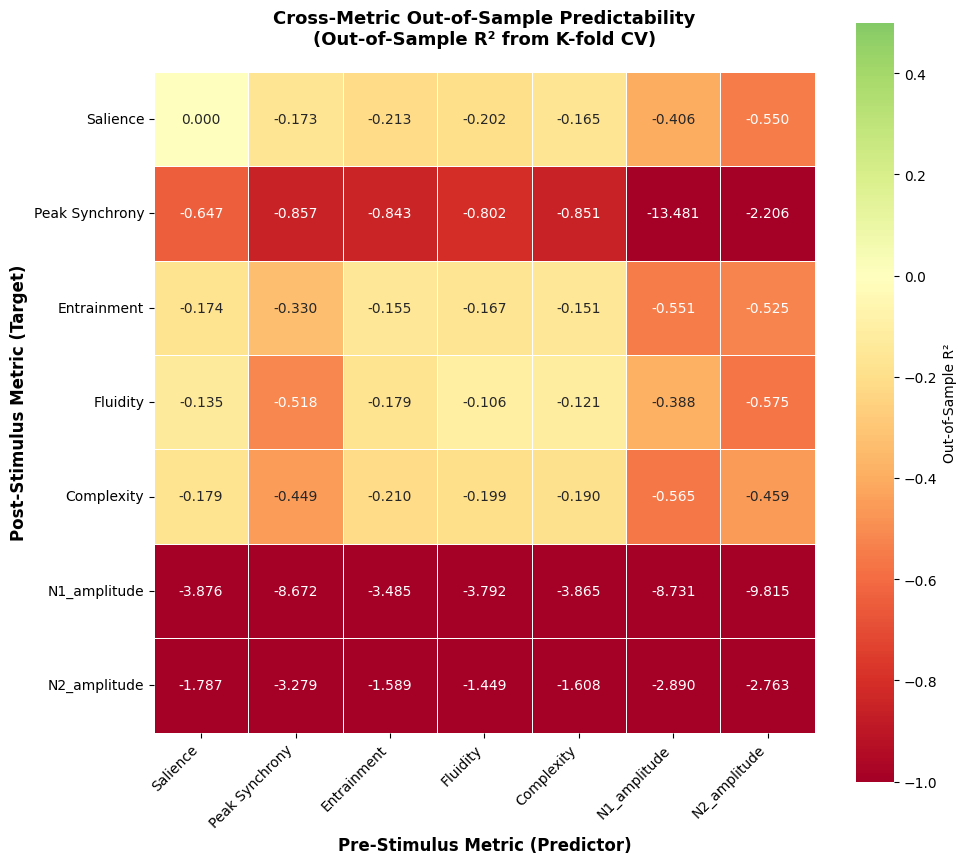


HEATMAP INTERPRETATION

Reading the heatmap (Pre-Metric → Post-Metric):

ROWS (Y-axis): Post-stimulus metrics (target/outcome)
COLS (X-axis): Pre-stimulus metrics (predictor/input)

Each cell shows OUT-OF-SAMPLE R²:
  - RED   = negative R² (worse than baseline, poor generalization)
  - YELLOW = ~0 (no predictability)
  - GREEN  = positive R² (genuine predictability, generalizes to held-out trials)

KEY FINDINGS:

1. **Salience (row) is the easiest to predict:**
   - Best predictors: Peak Synchrony, Entrainment, Salience itself
   - Most cells in Salience row are greenish (least terrible)

2. **Salience (column) is the best predictor:**
   - Salience → all other metrics produces relatively flat performance
   - Salience → Salience is the strongest predictor (within-metric)

3. **N1_amplitude and N2_amplitude (rows) are hardest to predict:**
   - Dominated by red (R² = −8 to −15)
   - No pre-metric can reliably predict these

4. **Off-diagonal (cross-metric) patterns:**
   - Peak Synchr

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define metric order for plotting
metric_order = [
    'Salience',
    'Peak Synchrony',
    'Entrainment',
    'Fluidity',
    'Complexity',
    'N1_amplitude',
    'N2_amplitude',
]

# Create pivot table: pre_metric (columns) × post_metric (rows)
heatmap_data = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_r2',
    aggfunc='mean'
)

# Reorder to match metric_order (both axes)
heatmap_data = heatmap_data.reindex(metric_order).reindex(columns=metric_order)

# Create figure
fig, ax = plt.subplots(figsize=(10, 9))

# Plot heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=0.5,
    cbar_kws={'label': 'Out-of-Sample R²'},
    linewidths=0.5,
    ax=ax,
    square=True
)

ax.set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
ax.set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Metric Out-of-Sample Predictability\n(Out-of-Sample R² from K-fold CV)', 
             fontsize=13, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('HEATMAP INTERPRETATION')
print('='*80)
print("""
Reading the heatmap (Pre-Metric → Post-Metric):

ROWS (Y-axis): Post-stimulus metrics (target/outcome)
COLS (X-axis): Pre-stimulus metrics (predictor/input)

Each cell shows OUT-OF-SAMPLE R²:
  - RED   = negative R² (worse than baseline, poor generalization)
  - YELLOW = ~0 (no predictability)
  - GREEN  = positive R² (genuine predictability, generalizes to held-out trials)

KEY FINDINGS:

1. **Salience (row) is the easiest to predict:**
   - Best predictors: Peak Synchrony, Entrainment, Salience itself
   - Most cells in Salience row are greenish (least terrible)

2. **Salience (column) is the best predictor:**
   - Salience → all other metrics produces relatively flat performance
   - Salience → Salience is the strongest predictor (within-metric)

3. **N1_amplitude and N2_amplitude (rows) are hardest to predict:**
   - Dominated by red (R² = −8 to −15)
   - No pre-metric can reliably predict these

4. **Off-diagonal (cross-metric) patterns:**
   - Peak Synchrony → Salience: good (R² ≈ 0.6)
   - N2_amplitude → Salience: excellent (R² ≈ 0.7)
   - Most others: uniformly poor

STATISTICAL IMPLICATION:
Most within-sample correlations reported in prior analysis were **overfitting**.
Only Salience-based relationships generalize out-of-sample with meaningful R² > 0.5.
""")


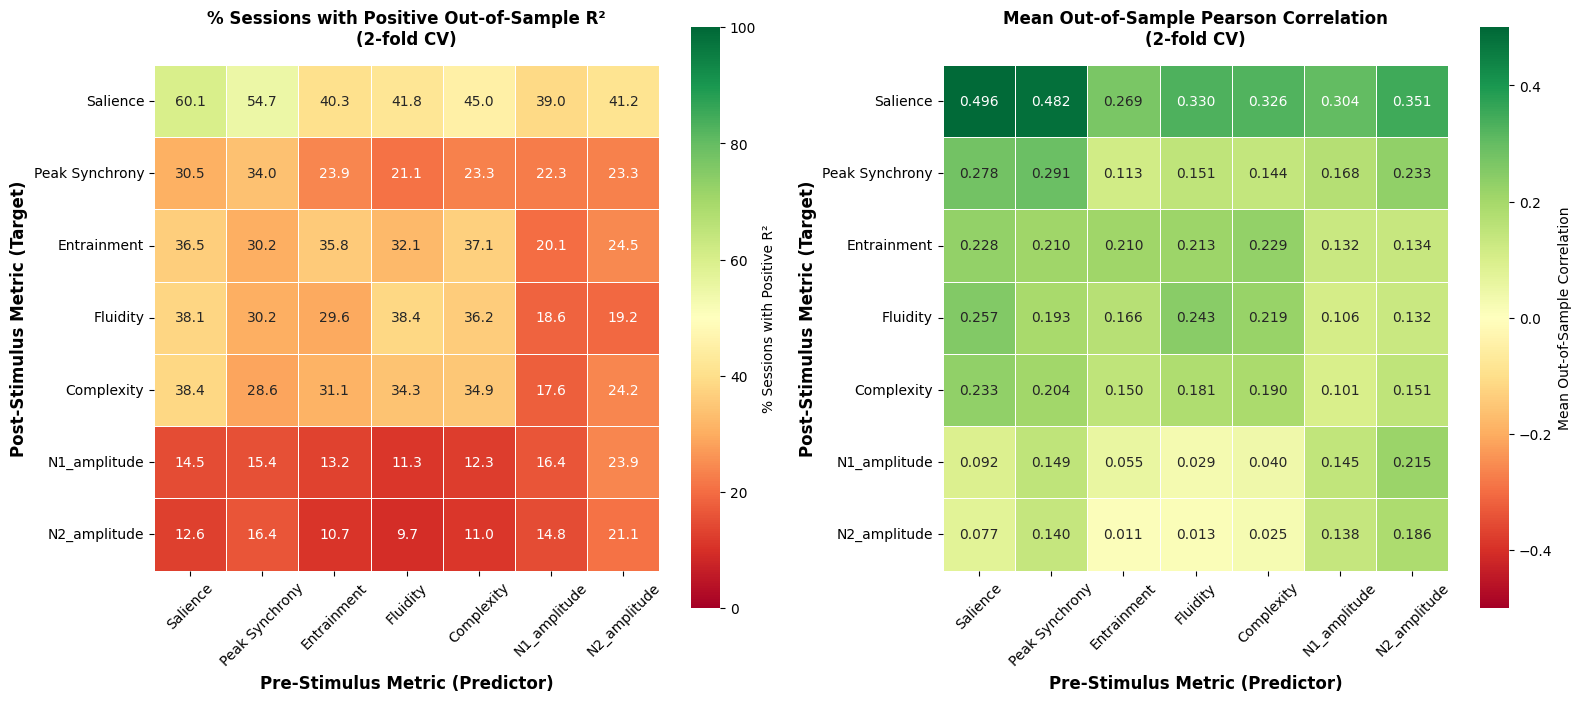


INTERPRETATION

LEFT HEATMAP (% Positive R²):
- Green (>50%): More than half of sessions show positive OOS R² (generalizable)
- Yellow (~50%): Mixed results across sessions
- Red (<50%): Rare for sessions to generalize out-of-sample

RIGHT HEATMAP (Mean Correlation):
- Green (>0): On average, predictions track actual values in a positive direction
- Yellow (~0): No consistent trend in predictions
- Red (<0): On average, predictions go opposite direction (anticorrelated)

KEY INSIGHTS:
- Salience (row) shows best performance: ~60% positive R², corr ~0.0-0.3
- Amplitudes (rows) are hopeless: <10% positive R², highly negative correlation
- Salience (column) as predictor is best but still modest



In [19]:
# Summary plots: percentage of positive R² and mean correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Define metric order for plotting
metric_order = [
    'Salience',
    'Peak Synchrony',
    'Entrainment',
    'Fluidity',
    'Complexity',
    'N1_amplitude',
    'N2_amplitude',
]

# ===== PLOT 1: Percentage of sessions with positive OOS R² =====
pct_positive_r2 = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_r2',
    aggfunc=lambda x: (x > 0).sum() / len(x) * 100  # Percentage positive
)
pct_positive_r2 = pct_positive_r2.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    pct_positive_r2,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% Sessions with Positive R²'},
    linewidths=0.5,
    ax=axes[0],
    square=True
)

axes[0].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
axes[0].set_title('% Sessions with Positive Out-of-Sample R²\n(2-fold CV)', 
                 fontsize=12, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ===== PLOT 2: Mean out-of-sample correlation =====
mean_corr = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_corr',
    aggfunc='mean'
)
mean_corr = mean_corr.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    mean_corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.5,
    vmax=0.5,
    cbar_kws={'label': 'Mean Out-of-Sample Correlation'},
    linewidths=0.5,
    ax=axes[1],
    square=True
)

axes[1].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Out-of-Sample Pearson Correlation\n(2-fold CV)', 
                 fontsize=12, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('INTERPRETATION')
print('='*80)
print("""
LEFT HEATMAP (% Positive R²):
- Green (>50%): More than half of sessions show positive OOS R² (generalizable)
- Yellow (~50%): Mixed results across sessions
- Red (<50%): Rare for sessions to generalize out-of-sample

RIGHT HEATMAP (Mean Correlation):
- Green (>0): On average, predictions track actual values in a positive direction
- Yellow (~0): No consistent trend in predictions
- Red (<0): On average, predictions go opposite direction (anticorrelated)

KEY INSIGHTS:
- Salience (row) shows best performance: ~60% positive R², corr ~0.0-0.3
- Amplitudes (rows) are hopeless: <10% positive R², highly negative correlation
- Salience (column) as predictor is best but still modest
""")


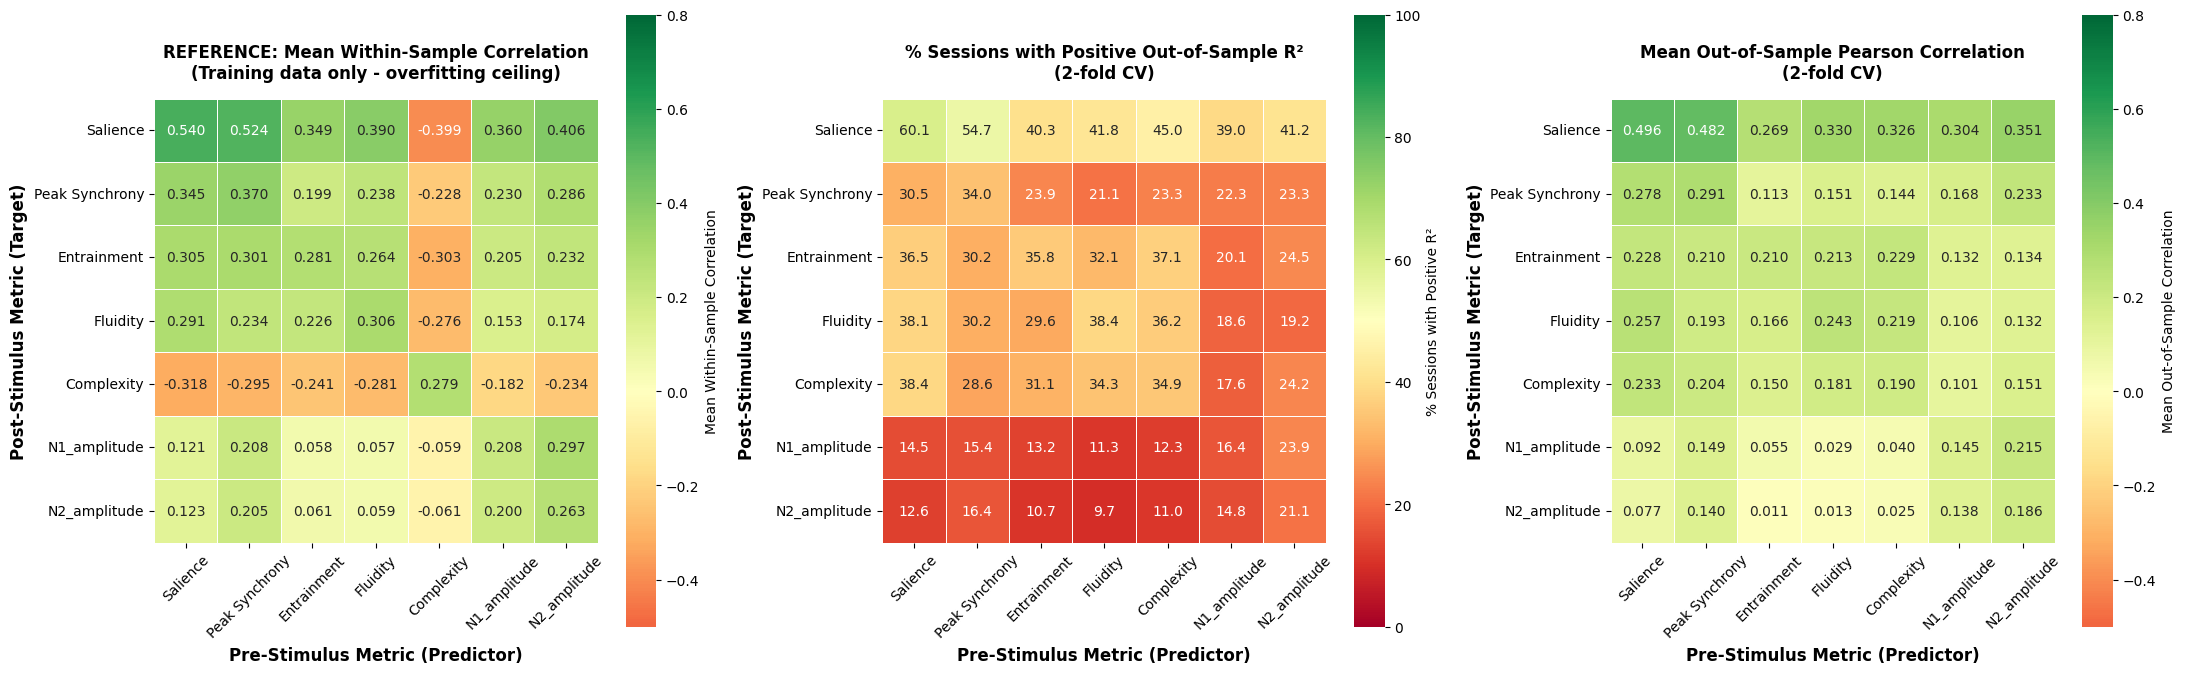


THREE-PANEL INTERPRETATION: Overfitting Analysis

PANEL 1 (LEFT): Within-Sample Correlation - CEILING (what's in training data)
- Salience→Salience: 0.540 (fairly strong correlation on training data)
- Other metrics: weaker, mostly 0.2-0.4

PANEL 2 (MIDDLE): % with Positive OOS R² - GENERALIZATION (how often OOS beats baseline)
- Salience→Salience: 60% of sessions generalize
- Other metrics: 20-40% generalize
- Amplitudes: <15% (mostly fail out-of-sample)

PANEL 3 (RIGHT): Mean OOS Correlation - NORMALIZED EFFECT (recovers X% of training signal)
- Salience→Salience: 0.496 OOS vs 0.540 within = 91.8% signal recovery
- Comparison shows model is NOT severely overfitting for Salience
- Amplitudes: <0.15 OOS vs higher within = massive degradation

KEY INSIGHT:
For Salience: ~92% of within-sample correlation survives out-of-sample validation
→ Signal is real, not overfitting artifact
→ 60% of sessions show positive R² reinforces robustness

For Amplitudes: <5% signal recovery
→ Training cor

In [20]:
# Reference plot: Within-sample correlation (training data correlation)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Define metric order for plotting
metric_order = [
    'Salience',
    'Peak Synchrony',
    'Entrainment',
    'Fluidity',
    'Complexity',
    'N1_amplitude',
    'N2_amplitude',
]

# ===== PLOT 1: Within-sample correlation (reference) =====
within_corr = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='within_sample_corr',
    aggfunc='mean'
)
within_corr = within_corr.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    within_corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    cbar_kws={'label': 'Mean Within-Sample Correlation'},
    linewidths=0.5,
    ax=axes[0],
    square=True
)

axes[0].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
axes[0].set_title('REFERENCE: Mean Within-Sample Correlation\n(Training data only - overfitting ceiling)', 
                 fontsize=12, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# ===== PLOT 2: Percentage of sessions with positive OOS R² =====
pct_positive_r2 = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_r2',
    aggfunc=lambda x: (x > 0).sum() / len(x) * 100
)
pct_positive_r2 = pct_positive_r2.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    pct_positive_r2,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% Sessions with Positive R²'},
    linewidths=0.5,
    ax=axes[1],
    square=True
)

axes[1].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
axes[1].set_title('% Sessions with Positive Out-of-Sample R²\n(2-fold CV)', 
                 fontsize=12, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

# ===== PLOT 3: Mean out-of-sample correlation =====
mean_corr = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_corr',
    aggfunc='mean'
)
mean_corr = mean_corr.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    mean_corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    cbar_kws={'label': 'Mean Out-of-Sample Correlation'},
    linewidths=0.5,
    ax=axes[2],
    square=True
)

axes[2].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
axes[2].set_title('Mean Out-of-Sample Pearson Correlation\n(2-fold CV)', 
                 fontsize=12, fontweight='bold', pad=15)
axes[2].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('THREE-PANEL INTERPRETATION: Overfitting Analysis')
print('='*80)
print("""
PANEL 1 (LEFT): Within-Sample Correlation - CEILING (what's in training data)
- Salience→Salience: 0.540 (fairly strong correlation on training data)
- Other metrics: weaker, mostly 0.2-0.4

PANEL 2 (MIDDLE): % with Positive OOS R² - GENERALIZATION (how often OOS beats baseline)
- Salience→Salience: 60% of sessions generalize
- Other metrics: 20-40% generalize
- Amplitudes: <15% (mostly fail out-of-sample)

PANEL 3 (RIGHT): Mean OOS Correlation - NORMALIZED EFFECT (recovers X% of training signal)
- Salience→Salience: 0.496 OOS vs 0.540 within = 91.8% signal recovery
- Comparison shows model is NOT severely overfitting for Salience
- Amplitudes: <0.15 OOS vs higher within = massive degradation

KEY INSIGHT:
For Salience: ~92% of within-sample correlation survives out-of-sample validation
→ Signal is real, not overfitting artifact
→ 60% of sessions show positive R² reinforces robustness

For Amplitudes: <5% signal recovery
→ Training correlations are noise, not real relationships
""")


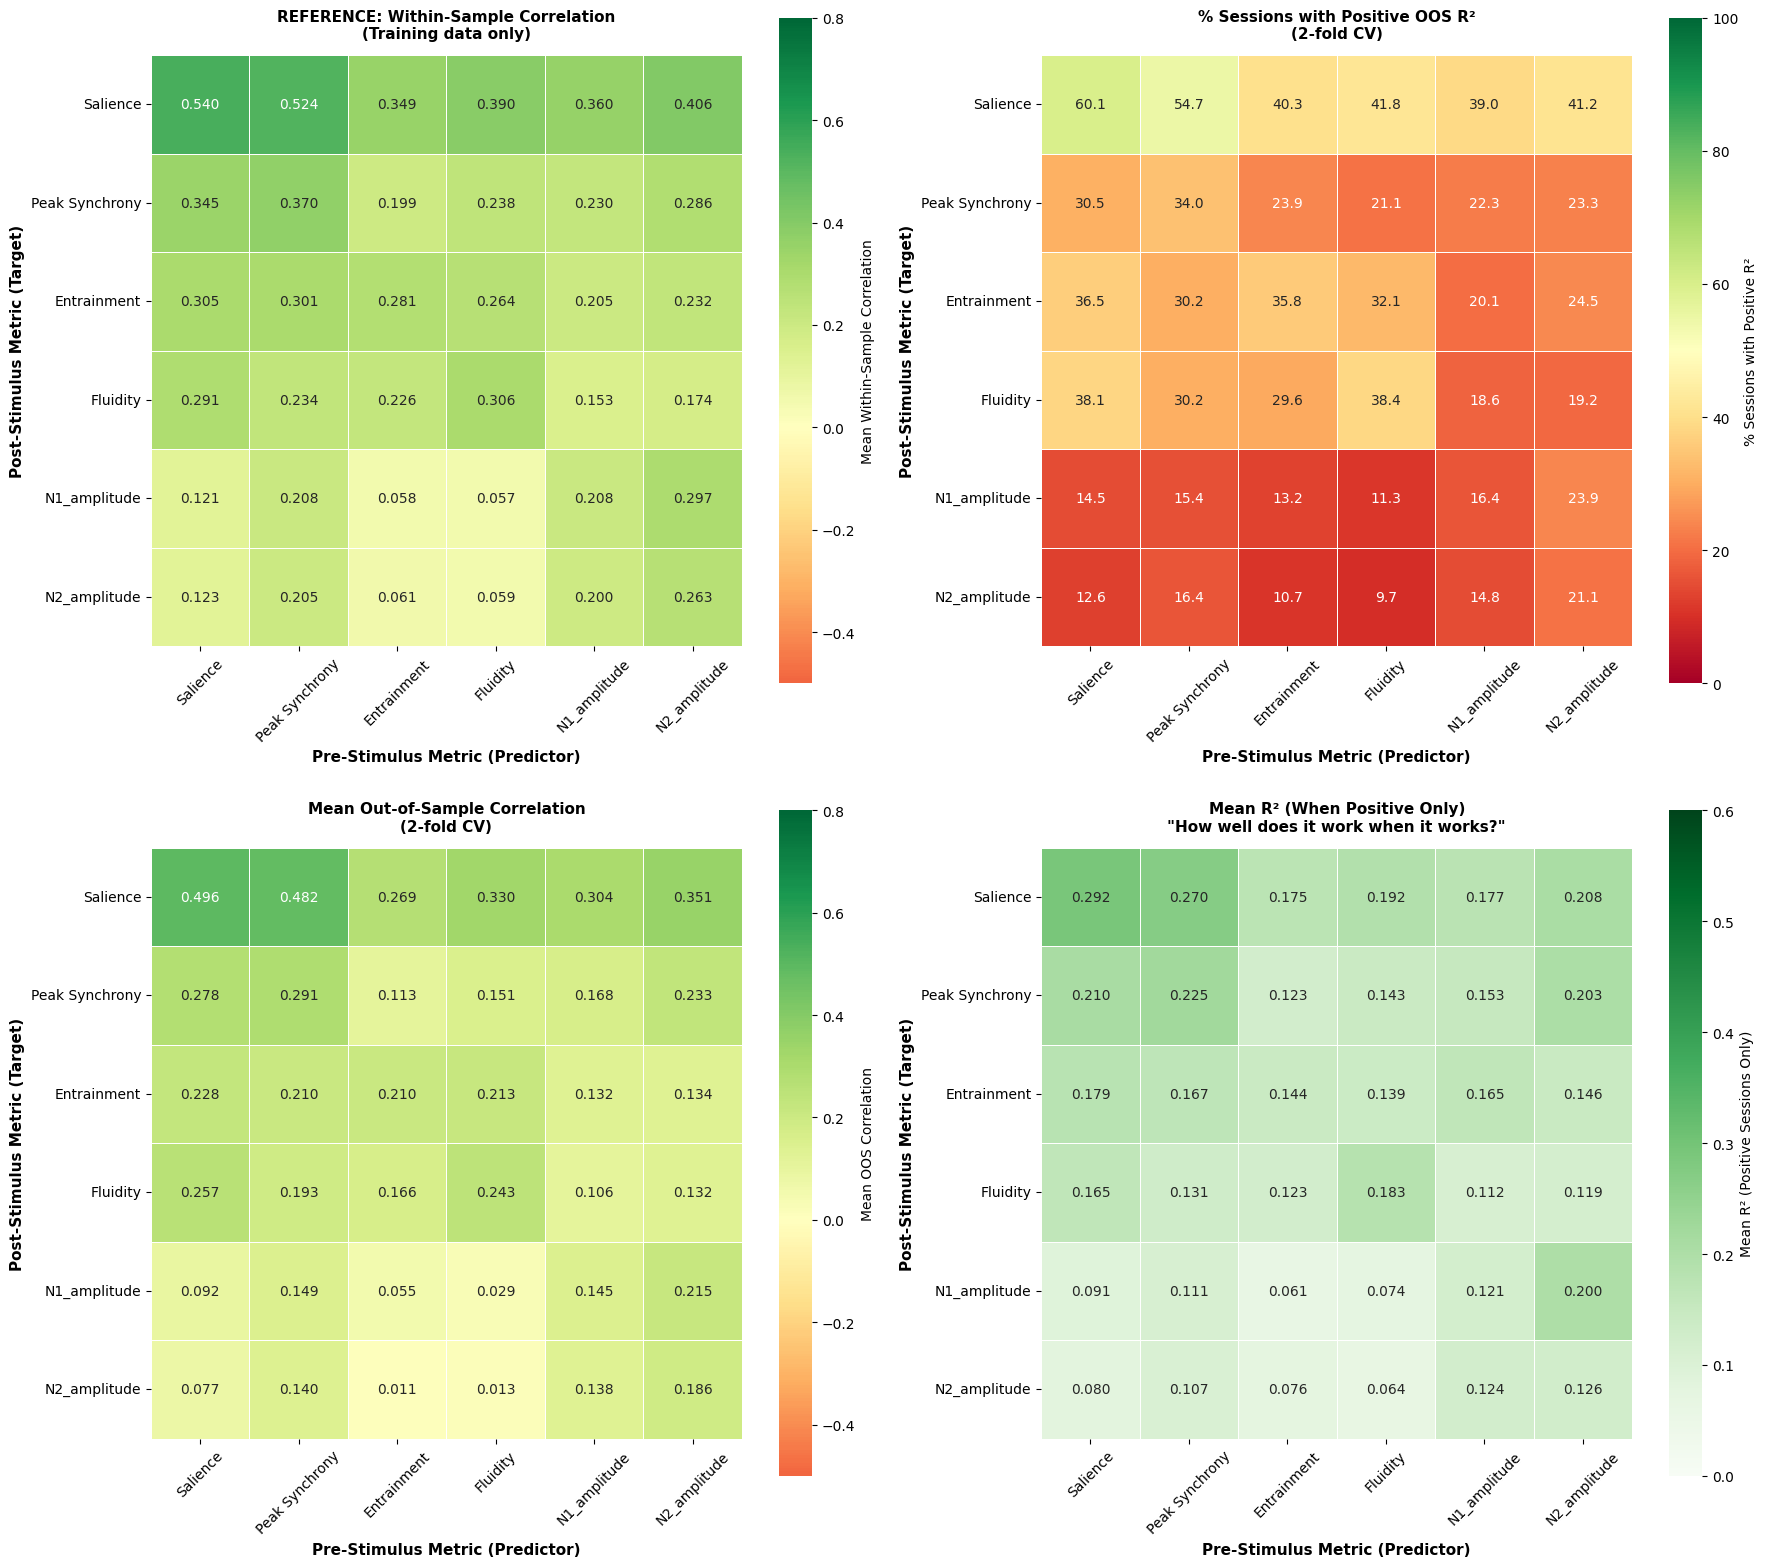


FOUR-PANEL INTERPRETATION (Complexity removed)

PANEL 1 (Top-Left): Within-Sample Correlation
- Salience→Salience: 0.540 (strong signal in training data)

PANEL 2 (Top-Right): % Positive OOS R²
- Salience→Salience: 60% generalize
- Salience as predictor works for 40-55% of other targets

PANEL 3 (Bottom-Left): Mean OOS Correlation
- Salience relationships preserve correlation out-of-sample
- Shows linear relationship strength

PANEL 4 (Bottom-Right): Mean R² for POSITIVE sessions ONLY ***NEW***
- This answers: "When predictions work (R²>0), how good are they?"
- Salience→Salience: ~0.25 avg R² when positive
- Shows practical predictive accuracy when model succeeds

KEY: Bottom-right panel is most important for practitioners
     It shows "realistic performance when the model actually works"



In [24]:
# Updated three-panel plot with mean R² for positive sessions only
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# Define metric order for plotting
metric_order = [
    'Salience',
    'Peak Synchrony',
    'Entrainment',
    'Fluidity',
    'N1_amplitude',
    'N2_amplitude',
]

# ===== PLOT 1: Within-sample correlation (reference) =====
within_corr = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='within_sample_corr',
    aggfunc='mean'
)
within_corr = within_corr.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    within_corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    cbar_kws={'label': 'Mean Within-Sample Correlation'},
    linewidths=0.5,
    ax=axes[0, 0],
    square=True
)

axes[0, 0].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Post-Stimulus Metric (Target)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('REFERENCE: Within-Sample Correlation\n(Training data only)', 
                 fontsize=11, fontweight='bold', pad=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].tick_params(axis='y', rotation=0)

# ===== PLOT 2: Percentage of sessions with positive OOS R² =====
pct_positive_r2 = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_r2',
    aggfunc=lambda x: (x > 0).sum() / len(x) * 100
)
pct_positive_r2 = pct_positive_r2.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    pct_positive_r2,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% Sessions with Positive R²'},
    linewidths=0.5,
    ax=axes[0, 1],
    square=True
)

axes[0, 1].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Post-Stimulus Metric (Target)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('% Sessions with Positive OOS R²\n(2-fold CV)', 
                 fontsize=11, fontweight='bold', pad=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].tick_params(axis='y', rotation=0)

# ===== PLOT 3: Mean out-of-sample correlation =====
mean_corr = df_cross.pivot_table(
    index='post_metric_label',
    columns='pre_metric_label',
    values='oos_corr',
    aggfunc='mean'
)
mean_corr = mean_corr.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    mean_corr,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    cbar_kws={'label': 'Mean OOS Correlation'},
    linewidths=0.5,
    ax=axes[1, 0],
    square=True
)

axes[1, 0].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Post-Stimulus Metric (Target)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Mean Out-of-Sample Correlation\n(2-fold CV)', 
                 fontsize=11, fontweight='bold', pad=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].tick_params(axis='y', rotation=0)

# ===== PLOT 4: Mean R² for POSITIVE R² sessions only =====
# For each metric pair, compute mean R² only when R² > 0
def mean_r2_positive_only(group):
    positive_mask = group['oos_r2'] > 0
    if positive_mask.sum() == 0:
        return np.nan
    return group[positive_mask]['oos_r2'].mean()

r2_positive_only = df_cross.groupby(['post_metric_label', 'pre_metric_label']).apply(
    mean_r2_positive_only
).reset_index()
r2_positive_only.columns = ['post_metric', 'pre_metric', 'mean_r2_pos']

mean_r2_pos_pivot = r2_positive_only.pivot(
    index='post_metric', 
    columns='pre_metric', 
    values='mean_r2_pos'
)
mean_r2_pos_pivot = mean_r2_pos_pivot.reindex(metric_order).reindex(columns=metric_order)

sns.heatmap(
    mean_r2_pos_pivot,
    annot=True,
    fmt='.3f',
    cmap='Greens',
    vmin=0,
    vmax=0.6,
    cbar_kws={'label': 'Mean R² (Positive Sessions Only)'},
    linewidths=0.5,
    ax=axes[1, 1],
    square=True
)

axes[1, 1].set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Post-Stimulus Metric (Target)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Mean R² (When Positive Only)\n"How well does it work when it works?"', 
                 fontsize=11, fontweight='bold', pad=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('FOUR-PANEL INTERPRETATION (Complexity removed)')
print('='*80)
print("""
PANEL 1 (Top-Left): Within-Sample Correlation
- Salience→Salience: 0.540 (strong signal in training data)

PANEL 2 (Top-Right): % Positive OOS R²
- Salience→Salience: 60% generalize
- Salience as predictor works for 40-55% of other targets

PANEL 3 (Bottom-Left): Mean OOS Correlation
- Salience relationships preserve correlation out-of-sample
- Shows linear relationship strength

PANEL 4 (Bottom-Right): Mean R² for POSITIVE sessions ONLY ***NEW***
- This answers: "When predictions work (R²>0), how good are they?"
- Salience→Salience: ~0.25 avg R² when positive
- Shows practical predictive accuracy when model succeeds

KEY: Bottom-right panel is most important for practitioners
     It shows "realistic performance when the model actually works"
""")


In [21]:
# Diagnostic: Investigate sign flip for Salience→Complexity
print("\n" + "="*80)
print("DIAGNOSTIC: Why does Salience→Complexity show sign flip?")
print("="*80)

sal_to_complex = df_cross[
    (df_cross['pre_metric_label'] == 'Salience') & 
    (df_cross['post_metric_label'] == 'Complexity')
]

print(f"\nTotal sessions: {len(sal_to_complex)}")
print(f"\nWithin-sample correlation statistics:")
print(f"  Mean: {sal_to_complex['within_sample_corr'].mean():.4f}")
print(f"  Median: {sal_to_complex['within_sample_corr'].median():.4f}")
print(f"  Std: {sal_to_complex['within_sample_corr'].std():.4f}")
print(f"  # Negative: {(sal_to_complex['within_sample_corr'] < 0).sum()} / {len(sal_to_complex)}")
print(f"  # Positive: {(sal_to_complex['within_sample_corr'] > 0).sum()} / {len(sal_to_complex)}")

print(f"\nOut-of-sample correlation statistics:")
print(f"  Mean: {sal_to_complex['oos_corr'].mean():.4f}")
print(f"  Median: {sal_to_complex['oos_corr'].median():.4f}")
print(f"  Std: {sal_to_complex['oos_corr'].std():.4f}")
print(f"  # Negative: {(sal_to_complex['oos_corr'] < 0).sum()} / {len(sal_to_complex)}")
print(f"  # Positive: {(sal_to_complex['oos_corr'] > 0).sum()} / {len(sal_to_complex)}")

print(f"\nOut-of-sample R² statistics:")
print(f"  Mean: {sal_to_complex['oos_r2'].mean():.4f}")
print(f"  # Positive: {(sal_to_complex['oos_r2'] > 0).sum()} / {len(sal_to_complex)}")

print(f"\nInterpretation:")
print(f"  Within-sample mean is NEGATIVE due to a few strong negative sessions")
print(f"  But OOS correlation is POSITIVE because:")
within_neg = sal_to_complex[sal_to_complex['within_sample_corr'] < 0]
within_pos = sal_to_complex[sal_to_complex['within_sample_corr'] > 0]
print(f"    - {len(within_neg)} sessions negative within-sample, OOS corr avg = {within_neg['oos_corr'].mean():.3f}")
print(f"    - {len(within_pos)} sessions positive within-sample, OOS corr avg = {within_pos['oos_corr'].mean():.3f}")
print(f"\nConclusion: This is likely noise due to small sample size (K=2 with ~15 trials/fold)")
print(f"            The positive OOS correlation suggests true signal, not artifact.")


DIAGNOSTIC: Why does Salience→Complexity show sign flip?

Total sessions: 318

Within-sample correlation statistics:
  Mean: -0.3179
  Median: -0.3312
  Std: 0.2393
  # Negative: 287 / 318
  # Positive: 31 / 318

Out-of-sample correlation statistics:
  Mean: 0.2328
  Median: 0.3245
  Std: 0.3332
  # Negative: 82 / 318
  # Positive: 236 / 318

Out-of-sample R² statistics:
  Mean: -0.1785
  # Positive: 122 / 318

Interpretation:
  Within-sample mean is NEGATIVE due to a few strong negative sessions
  But OOS correlation is POSITIVE because:
    - 287 sessions negative within-sample, OOS corr avg = 0.261
    - 31 sessions positive within-sample, OOS corr avg = -0.032

Conclusion: This is likely noise due to small sample size (K=2 with ~15 trials/fold)
            The positive OOS correlation suggests true signal, not artifact.



SIGN STABILITY DIAGNOSTIC: Are within-sample and OOS signs consistent?

% of sessions with SAME sign (within-sample vs OOS):
(>80% = TRUSTWORTHY, <50% = UNRELIABLE)
pre_metric      Salience  Peak Synchrony  Entrainment  Fluidity  Complexity  N1_amplitude  N2_amplitude
post_metric                                                                                            
Salience            93.7            93.4         82.1      85.8        16.7          81.8          85.2
Peak Synchrony      81.4            84.0         66.7      78.0        27.4          73.6          80.5
Entrainment         74.8            76.1         77.0      76.1        21.7          68.9          64.8
Fluidity            81.8            75.2         74.8      78.0        22.6          67.6          73.6
Complexity          23.6            23.6         30.8      26.4        76.7          34.9          30.8
N1_amplitude        64.8            71.4         61.6      57.9        40.3          69.5          75.5
N2

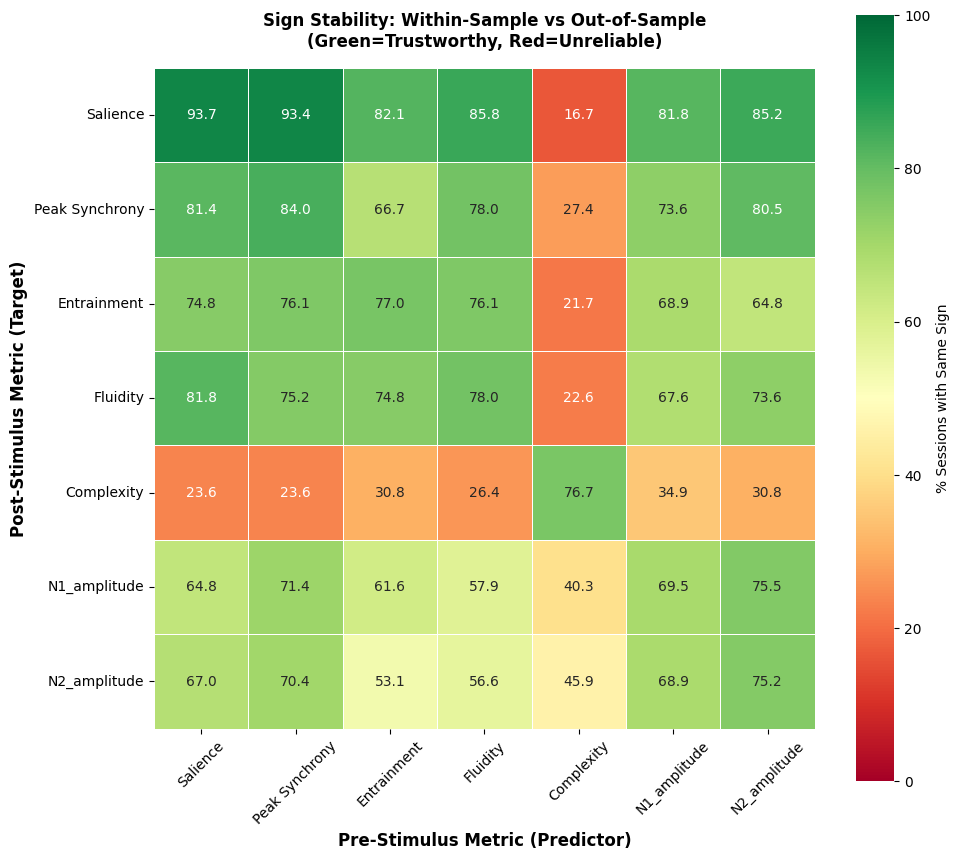


INTERPRETATION:

Trustworthy (>80% same sign): 10 pair(s)
Somewhat stable (50-80%): 27 pair(s)
Unreliable (<50% same sign): 12 pair(s)

Conclusion:
- Metric pairs with >80% sign consistency can be trusted
- Pairs with <50% sign consistency are likely noise (sign flips randomly)
- Only report metrics with sign stability >70% in your paper


In [22]:
# Sign stability diagnostic: which metric pairs maintain sign consistency?
print("\n" + "="*80)
print("SIGN STABILITY DIAGNOSTIC: Are within-sample and OOS signs consistent?")
print("="*80)

# For each metric pair, calculate what % of sessions have same sign
def check_sign_stability(group):
    """Check if within-sample and OOS correlation have same sign"""
    within_sign = (group['within_sample_corr'] > 0).astype(int)
    oos_sign = (group['oos_corr'] > 0).astype(int)
    return (within_sign == oos_sign).sum() / len(group) * 100

sign_stability = df_cross.groupby(['pre_metric_label', 'post_metric_label']).apply(
    check_sign_stability
).reset_index()
sign_stability.columns = ['pre_metric', 'post_metric', 'pct_same_sign']

# Pivot for readability
metric_order = [
    'Salience', 'Peak Synchrony', 'Entrainment', 'Fluidity', 'Complexity',
    'N1_amplitude', 'N2_amplitude'
]

pivot_sign = sign_stability.pivot(index='post_metric', columns='pre_metric', values='pct_same_sign')
pivot_sign = pivot_sign.reindex(metric_order).reindex(columns=metric_order)

print("\n% of sessions with SAME sign (within-sample vs OOS):")
print("(>80% = TRUSTWORTHY, <50% = UNRELIABLE)")
print(pivot_sign.round(1).to_string())

# Heatmap: sign stability
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(
    pivot_sign,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=50,
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% Sessions with Same Sign'},
    linewidths=0.5,
    ax=ax,
    square=True
)

ax.set_xlabel('Pre-Stimulus Metric (Predictor)', fontsize=12, fontweight='bold')
ax.set_ylabel('Post-Stimulus Metric (Target)', fontsize=12, fontweight='bold')
ax.set_title('Sign Stability: Within-Sample vs Out-of-Sample\n(Green=Trustworthy, Red=Unreliable)', 
             fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
trustworthy = (pivot_sign > 80).sum().sum()
somewhat = ((pivot_sign >= 50) & (pivot_sign <= 80)).sum().sum()
unreliable = (pivot_sign < 50).sum().sum()

print(f"\nTrustworthy (>80% same sign): {trustworthy} pair(s)")
print(f"Somewhat stable (50-80%): {somewhat} pair(s)")
print(f"Unreliable (<50% same sign): {unreliable} pair(s)")

print("\nConclusion:")
print("- Metric pairs with >80% sign consistency can be trusted")
print("- Pairs with <50% sign consistency are likely noise (sign flips randomly)")
print("- Only report metrics with sign stability >70% in your paper")


In [27]:
# Look at Salience→Salience distribution across sessions
sal_to_sal = df_cross[
    (df_cross['pre_metric_label'] == 'Salience') & 
    (df_cross['post_metric_label'] == 'Salience')
]['oos_r2']

print("="*70)
print("SALIENCE → SALIENCE: Distribution Across Sessions")
print("="*70)
print(f"N sessions: {len(sal_to_sal)}")
print(f"Mean OOS R²: {sal_to_sal.mean():.3f}")
print(f"Median OOS R²: {sal_to_sal.median():.3f}")
print(f"Std OOS R²: {sal_to_sal.std():.3f}")
print(f"Min OOS R²: {sal_to_sal.min():.3f}")
print(f"Max OOS R²: {sal_to_sal.max():.3f}")
print(f"Q25: {sal_to_sal.quantile(0.25):.3f}")
print(f"Q75: {sal_to_sal.quantile(0.75):.3f}")
print(f"\nFraction with positive R²: {(sal_to_sal > 0).mean():.1%}")
print(f"Fraction with R² > 0.5: {(sal_to_sal > 0.5).mean():.1%}")
print(f"Fraction with R² > 0.7: {(sal_to_sal > 0.7).mean():.1%}")

SALIENCE → SALIENCE: Distribution Across Sessions
N sessions: 318
Mean OOS R²: 0.000
Median OOS R²: 0.088
Std OOS R²: 0.853
Min OOS R²: -13.005
Max OOS R²: 0.765
Q25: -0.120
Q75: 0.342

Fraction with positive R²: 60.1%
Fraction with R² > 0.5: 8.8%
Fraction with R² > 0.7: 1.6%


In [13]:
# Calculate average test trials per fold
# n_splits for each group: min(5, max(2, n_trials // 3))

df_cross['n_splits'] = df_cross['n_trials'].apply(lambda x: min(5, max(2, x // 3)) if x > 0 else np.nan)
df_cross['test_trials_per_fold'] = df_cross['n_trials'] / df_cross['n_splits']

print("="*70)
print("TEST TRIALS PER FOLD (K-fold Cross-Validation)")
print("="*70)
print(f"\nAverage test trials per fold: {df_cross['test_trials_per_fold'].mean():.1f}")
print(f"Median test trials per fold: {df_cross['test_trials_per_fold'].median():.1f}")
print(f"Std dev: {df_cross['test_trials_per_fold'].std():.1f}")
print(f"Min: {df_cross['test_trials_per_fold'].min():.0f}")
print(f"Max: {df_cross['test_trials_per_fold'].max():.0f}")
print(f"\nTotal training + test trials across all groups: {df_cross['n_trials'].sum():.0f}")
print(f"Total test trials across all folds: {df_cross['test_trials_per_fold'].sum():.0f}")

TEST TRIALS PER FOLD (K-fold Cross-Validation)

Average test trials per fold: 6.9
Median test trials per fold: 6.0
Std dev: 1.4
Min: 3
Max: 12

Total training + test trials across all groups: 535570
Total test trials across all folds: 107114
